## Integrasi Numerik

Suatu fungsi $f(x)$ membentuk suatu kurva tidak beraturan yang memiliki batasan nilai, yaitu nilai minimum ($x_i$) dan nilai maksimum ($x_f$), maka luasan di bawah kurva tersebut bisa dihitung dengan membuat segmentasi kecil-kecil yang memiliki selang sama kemudian dijumlahkan seluruhnya. Konsep ini kemudian disebut dengan pendekatan integrasi numerik. Integrasi numerik adalah solusi untuk menyelesaikan fungsi integral ($\int$) yang tidak memiliki solusi secara analitik atau memiliki persamaan baku.

Contoh sederhanaya bisa dilihat pada kurva hubungan antara kecepatan terhadap waktu dari implementasi Gerak Lurus Beraturan (GLBB) seperti pada gambar berikut. Luasan di bawah kurva tersebut adalah total jarak yang ditempuh oleh suatu objek, dimana rumus yang digunakan untuk menyelesaikan permasalahan ini adalah

$s = v_0 t + \frac {1}{2} a t^2$

karena objek bergerak dari posisi awal dengan kecepatan awal ($v_0 = 0$), maka persamaannya menjadi

$s = \frac {1}{2} a t^2$

dimana $a=\frac {v}{t}$, maka

$s = \frac {1}{2} \frac {v}{t} t^2 = \frac {1}{2} v t$

Kita coba buat kode porogram python sederhana untuk menghitung total jarak berdasarkan rumus di atas, jika diketahui waktu tempuh objek ($t_f$) selama 10 detik dengan selang waktu ($dt$) 1 detik dan perubahan kecepatan setiap 10 m/s hingga mencapai kecepatan akhir 100 m/s.

Total jarak yang ditemput adalah : 500.0 meter


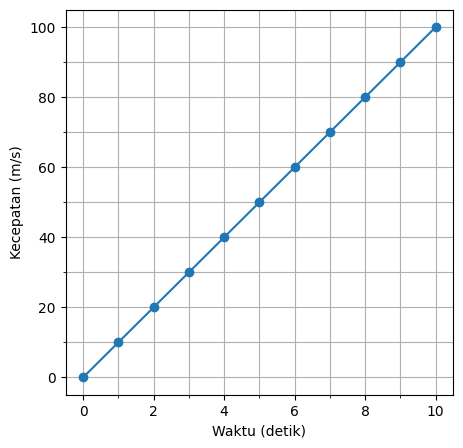

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

t0 = 0
tf = 10 # detik
dt = 1
t = np.arange(t0,tf+dt,dt)

v0 = 0
vf = 100 # meter
dv = 10
v = np.arange(v0,vf+dv,dv)

# Hitung total jarak yang ditempuh
s = 0.5 * vf * tf
print(f"Total jarak yang ditemput adalah : {s} meter")

fig,ax = plt.subplots(figsize=(5,5))
ax.plot(t,v,'-o')
ax.set(xlabel='Waktu (detik)',
       ylabel='Kecepatan (m/s)',
       axisbelow=True)
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(10))
plt.grid(which='both')

- lama waktu yang diperlukan adalah, $t_f=10$ detik

- kecepatan akhir mencapai, $v_f = 100$ m/s

maka

$s = \frac {1}{2} v_f t_f = \frac {1}{2} * 100 * 10 = 500$ meter

Hasil perhitungan sederhana diperoleh total jarak (sama dengan luasan di bawah kurva) adalah 500 meter.

Secara matematika, persamaan $s = \frac {1}{2} a t^2$, adalah integral perubahan kecepatan terhadap waktu, yaitu

$\frac {ds}{dt} = v$

$ds = v dt$

$s = \int v dt = \int a t dt = a \int t dt = a \frac {1}{2} t^2 = \frac {1}{2} a t^2$,

maka fungsi integralnya adalah

$s = \int_0^t a t dt $

dengan $a$ adalah percepatan dalam $m/s^2$.

Menggunakan contoh di atas, kita bisa menerapkan pendekatan integrasi numerik melalui beberapa metode, yaitu metode Trapezoidal dan Simpson.

### Metode Integrasi Trapezoidal (Trapesium)

Persamaan yang digunakan untuk menyelesaikan integrasi menggunakan metode trapesium adalah

$I = \int_a^b f(x) dx = \frac {h}{2} (f(a) + f(b))$

dimana $h$ adalah selisih $h = b-a$, untuk $a$ adalah batas awal dan $b$ batas akhir.

Kita coba implementasikan dengan menggunakan fungsi

$s = \int_{t_0}^{t_f} a t dt$

untuk menghitung total jarak yang ditempuh oleh suatu objek.

Jika percepatan suatu objek bergerak konstan $a=10$ $m/s^2$ dari $t_0=0$ hingga $t_f=10$ detik, maka total jarak yang ditempuhnya berdasarkan metode trapezoidal persamaan di atas dapat diselesaikan sebagai berikut.

- Hitung selisih batas

  - $h = b - a = 10 - 0 = 10$

- Hitung integrasi

    - $s = \int_0^{10} a t dt = \frac {10}{2} (10*0 + 10*10) = 5 * (0 + 100) = 500$ meter.
    

  Hasilnya sama seperti pendekatakan analitikal sebelumnya.

Pendekatan integrasi numerik trapezoidal di atas hanya menggunakan dua segmentasi nilai, yaitu $a$ dan $b$, tanpa dilakukan segmentasi menjadi lebih kecil lagi untuk setiap selang data ($dt$). Jika segmentasi diperbanyak ekuivalen dengan selang antar data ($dt$) semakin kecil, maka bentuk persamaan integrasi trapezoidal menjadi sebagai berikut

$I = \frac {h}{2} [f(x_0) + 2 \Sigma_{i=1}^{n-1} f(x_i) + f(x_n)]$

dimana $n$ adalah jumlah segmen dari $i=1,2,3,...,n-1$

Menggunakan contoh yang sama seperti di atas, dimana

$\int_{t_0}^{t_f} f(t) dt = \int_{t_0}^{t_f} a t dt$

dan $t_0 = 0$, $t_f=10$, $dt=1$

sehingga banyak segmentasi bisa dihitung dengan persamaan berikut

$n = \frac {t_f - t_0}{dt} = \frac {10-0}{1} = 10$ segmen selama 10 detik maka

$h = dt = 1$.
  
- $f(t_1 = 1 | i = 1) = a t_1 = 10 * 1 = 10$ $m/s^2$
- $f(t_1 = 2 | i = 2) = a t_2 = 10 * 2 = 20$ $m/s^2$
- $f(t_3 = 3 | i = 3) = a t_3 = 10 * 3 = 30$ $m/s^2$
- $f(t_4 = 4 | i = 4) = a t_4 = 10 * 4 = 40$ $m/s^2$
- $f(t_5 = 5 | i = 5) = a t_5 = 10 * 5 = 50$ $m/s^2$
- $f(t_6 = 6 | i = 6) = a t_6 = 10 * 6 = 60$ $m/s^2$
- $f(t_7 = 7 | i = 7) = a t_7 = 10 * 7 = 70$ $m/s^2$
- $f(t_8 = 8 | i = 8) = a t_8 = 10 * 8 = 80$ $m/s^2$
- $f(t_9 = 9 | i = 9) = a t_9 = 10 * 9 = 90$ $m/s^2$

Sehingga,

$\Sigma_{i=1}^{i=9} f(x_i) = 450$

dan

$2 \Sigma_{i=1}^{i=9} f(x_i) = 2*450 = 900$

dimana

$f(t_0 = 0) = a t = 10 * 0 = 0$

$f(t_n = 10) = a t = 10 * 10 = 100$

maka

$I = \int_{t_0}^{t_f} a t dt = \frac {h}{2} [f(t_0) + 2 \Sigma_{i=1}^{n-1} f(t_i) + f(t_n)]$

$I = \frac {1}{2} [0 + 900 + 100)] = \frac {1}{2} 1000 = 500$

Dengan menambahkan segmentasi lebih banyak, hasil yang diperoleh sama seperti hasil dari proses analitik. Namun, contoh kasus ini terlalu ideal. Kenyataannya, antara hasil numerik dan analitik memiliki selisih yang tidak jauh berbeda secara umum, namun bukan berarti sama secara mutlak. Hal ini bergantung kepada fungsi matematika dan pengaturan parameter yang digunakan untuk memecahkan suatu permasalahan.

Mari kita coba implementasikan contoh kasus di atas menggunakan kode program Python sebagai berikut

In [2]:
# Integrasi Numerik Metode Trapezoidal

f = lambda a,t: a*t

t0 = 0 # detik
tf = 10 # detik
dt = 0.1 # selang data dalam detik
a = 10 # percepatan dalam m/s^2

# banyak segmentasi
n = int((tf-t0)/dt)
print(f"Terdapat {n} segmen")
h = dt

# hitung total dari bagian segmentasi
total_mid = 0
ti = dt
for i in range(1,n):
  total_mid = total_mid + f(a,ti)
  ti = ti + dt
total_mid = 2 * total_mid

# Hitung integral
integral_value = (h/2) * (f(a, t0) + total_mid + f(a, tf))

print(f"Total jarak yang ditempuh: {integral_value} m/s")


Terdapat 100 segmen
Total jarak yang ditempuh: 500.0 m/s


### Metode Integrasi Simpson

Integrasi numerik menggunakan Metode Simpson menerapkan pendekatan segmentasi parabolik dibandingkan pendekatan linear seperti metode trapezoidal. Secara numerik, metode ini memiliki dua bagian fungsi, yaitu fungsi pada indeks ganjil dan genap serta secara keseluruhan di bagi menjadi tiga titik seperti yang ditulis pada persamaan berikut

$I = \int_a^b f(x) dx = \frac {h}{3} (f(x_0) + 4\Sigma_{i=1}^{n/2} f(x_{2i-1}) + 2\Sigma_{i=i}^{n/2-1} f(x_{2i}) +  f(x_n))$

dimana $n/2$ adalah ganil dan $n/2 -1$ adalah genap. Persamaan numerik ini kemudan disebut dengan aturan Simpson 1/3.

Menggunakan contoh yang sama seperti di atas, dimana

$\int_{t_0}^{t_f} f(t) dt = \int_{t_0}^{t_f} a t dt$

dimana $t_0 = 0$, $t_f=10$, $dt=1$

sehingga banyak segmentasi bisa dihitung dengan persamaan berikut

$n = \frac {t_f - t_0}{dt} = \frac {10-0}{1} = 10$ segmen selama 10 detik maka

$h = dt = 1$.

Karena diketahui $n=10$, maka untuk

Segemen ganjil, $4\Sigma_{i=1}^{n/2} f(x_{2i-1})$, mengambil nilai $x$ dari nilai $x$ ke $i=1$ hingga $n/2 = 10/2 = 5$. Kemudian, untuk nilai $x$ itu sendiri adalah waktu untuk setiap selang waktu, $dt$, yang ganjil, maka selang waktu setiap data ganjil harus ditambah dengan $2*dt$

Selanjutnya, segmen genap, $2\Sigma_{i=i}^{n/2-1} f(x_{2i})$, mengambil nilai $x$ dari nilai $x$ ke $i=1$ hingga $n/2 - 1 = 10/2 - 1 = 5 - 1 = 4$. Kemudian, untuk nilai $x$ itu sendiri adalah waktu untuk setiap selang waktu, $dt$, yang genap, maka selang waktu setiap data genap harus ditambah dengan $2*dt$ dan nilai awal $dt$ dimulai dengan $dt=2*dt$.

Kita coba langsung implementasikan ke dalam program Python sebagai berikut

In [3]:
# Integrasi Numerik Metode Simpson (rule of 1/3)

f = lambda a,t: a*t

t0 = 0 # detik
tf = 10 # detik
dt = 1 # selang data dalam detik
a = 10 # percepatan dalam m/s^2

# banyak segmentasi
n = int((tf-t0)/dt)
print(f"Terdapat {n} segmen")
h = dt

# hitung total dari bagian segmentasi ganjil
total_ganjil = 0
ti = dt
for i in range(1,int(n/2+1)):
  total_ganjil = total_ganjil + f(a,ti)
  ti = ti + (2*dt)

# hitung total dari bagian segmentasi genap
total_genap = 0
ti = 2*dt
for i in range(1,int((n/2-1)+1)):
  total_genap = total_genap + f(a,ti)
  ti = ti + (2*dt)

# Hitung integral simpson
integral_value = (h/3) * (f(a,t0) + (4*total_ganjil) + (2*total_genap) + f(a,tf))

print(f"Total jarak yang ditempuh: {integral_value:.2f} m/s")


Terdapat 10 segmen
Total jarak yang ditempuh: 500.00 m/s
